<a href="https://colab.research.google.com/github/hemajuluri/Ethical-and-fairness/blob/main/01_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
# 1. Load the raw data
raw_data_path = '/content/drive/MyDrive/Thesis/src/data_raw/application_train.csv'
df = pd.read_csv(raw_data_path)

# 2. Take a 10% Stratified Sample for speed
def stratified_sample(df, stratify_col, frac, random_state=None):
    sampled_dfs = []
    for group_name, group_df in df.groupby(stratify_col):
        sampled_dfs.append(group_df.sample(frac=frac, random_state=random_state))
    return pd.concat(sampled_dfs)

df_sample = stratified_sample(df, 'TARGET', frac=0.1, random_state=42)

# 3. Define X and y
X = df_sample.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df_sample['TARGET']

# 4. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Sample size: {len(df_sample)} | Training size: {len(X_train)} | Test size: {len(X_test)}")

Mounted at /content/drive
Sample size: 30751 | Training size: 24600 | Test size: 6151


In [2]:
# Fix DAYS_EMPLOYED anomaly
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, df['DAYS_EMPLOYED'].median())

# Engineered features
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT']  / df['AMT_INCOME_TOTAL']
df['EMPLOYMENT_PERCENT']   = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
df['GOODS_PRICE_RATIO']    = df['AMT_CREDIT']  / df['AMT_GOODS_PRICE']
df['INCOME_PER_PERSON']    = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

In [3]:
# Exclude gender from model features
X = df_sample.drop(['TARGET', 'SK_ID_CURR', 'CODE_GENDER'], axis=1)

In [4]:
import os

# List contents of the mounted drive
print("Contents of /content/drive/MyDrive:")
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    level = root.replace('/content/drive/MyDrive', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

# Or for a more specific path if you know the general location
# print("\nContents of /content/drive/MyDrive/Thesis/src/data_raw:")
# print(os.listdir('/content/drive/MyDrive/Thesis/src/data_raw'))

Streaming output truncated to the last 5000 lines.
                        squamous cell carcinoma_original_ISIC_0029851.jpg_2b5e775b-8ff7-4103-a065-c9c621163d02.jpg
                        squamous cell carcinoma_original_ISIC_0033869.jpg_14b5f2c5-6e44-407d-9fa7-0cb3d55c5342.jpg
                        squamous cell carcinoma_original_ISIC_0029371.jpg_0edaed0a-6bda-4ac1-b5ad-3932ab217c7b.jpg
                        squamous cell carcinoma_original_ISIC_0031927.jpg_85c1d1b1-141f-40eb-9f19-0ef75cc51016.jpg
                        squamous cell carcinoma_original_ISIC_0028335.jpg_8358d5a4-f1d7-486a-af93-c6a52c5a7401.jpg
                        squamous cell carcinoma_original_ISIC_0026206.jpg_c7451e90-d094-4c60-8f9d-bcee49bfd89e.jpg
                        squamous cell carcinoma_original_ISIC_0032349.jpg_ebcd3592-1929-484b-9c2f-6d0dcb9638dd.jpg
                        squamous cell carcinoma_original_ISIC_0025331.jpg_2001265a-c0b0-414f-9ddd-82caaccd7c6f.jpg
                        squam

After running the above cell, carefully inspect the output to find the exact path to your `application_train.csv` file. Once you have the correct path, update the `raw_data_path` variable in the first code cell (`zenevoh1JZbF`) to reflect the correct location. For example, if your file is directly under `MyDrive`, you would change it to `'/content/drive/MyDrive/application_train.csv'`.

In [5]:
# 1. Mount and Imports
from google.colab import drive
import joblib
import pandas as pd
drive.mount('/content/drive')

# 2. Re-hydrate the "Baton"
save_path = '/content/drive/MyDrive/Thesis/src/artifacts/'
model_smote = joblib.load(f'{save_path}logistic_reg_smote_model.pkl')
preprocessor = joblib.load(f'{save_path}preprocessor_pipeline.pkl')
X_test = pd.read_csv(f'{save_path}X_test_final.csv')
y_test = pd.read_csv(f'{save_path}y_test_final.csv')

# 3. Re-process the test data (required for analysis)
X_test_proc = preprocessor.transform(X_test)

print("✅ State restored. You can now run any analysis cell below.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ State restored. You can now run any analysis cell below.


In [6]:
# Run this to verify the balance is preserved
print("Target distribution in Sample:")
print(df_sample['TARGET'].value_counts(normalize=True))

Target distribution in Sample:
TARGET
0    0.919287
1    0.080713
Name: proportion, dtype: float64


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Fit and transform
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [8]:
# 1. Check the type (Should be a numpy array or matrix)
print(f"Data Type: {type(X_train_proc)}")

# 2. Check the shape (The number of columns should have grown)
print(f"Original columns: {X_train.shape[1]}")
print(f"Processed columns: {X_train_proc.shape[1]}")

# 3. Peek at the first row of numbers
print("\nFirst row of processed data:")
print(X_train_proc[0])

Data Type: <class 'numpy.ndarray'>
Original columns: 120
Processed columns: 239

First row of processed data:
[-5.72705512e-01  1.55189132e+00  1.86315415e-01 -5.26717661e-01
  3.68095271e-01  7.19275859e-01 -9.87722140e-01  2.13091137e+00
  3.92939473e-01 -4.23687714e-01 -1.46166966e-01  0.00000000e+00
 -2.13114727e+00 -5.02539376e-01  4.23299276e-02 -6.23986810e-01
 -2.45558802e-01 -1.25608400e+00 -1.10544523e-01 -6.53969309e-02
  2.86506174e-01  7.78807649e+00 -2.33122205e-01 -2.06061218e-01
  3.40908453e+00 -5.49859328e-01 -4.68650316e-01  1.50975183e+00
  2.20082800e-01 -5.28083423e-01 -9.32620922e-01 -9.51047478e-02
  1.91513591e-01  1.14728671e+00 -1.61621482e-01 -3.67134018e-01
 -1.06722108e+00 -2.81042832e-01 -7.30110729e-02 -7.19210127e-01
 -1.42850918e-01 -8.99153992e-01 -1.04163189e-01 -2.26216643e-01
 -8.78888099e-01 -9.41364789e-02  1.82081423e-01  1.21778564e+00
 -1.63407287e-01 -3.55479207e-01 -1.02756853e+00 -2.65002831e-01
 -6.00070272e-02 -6.72136048e-01 -1.59277626e

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score
import datetime

# 1. Train Baseline (No SMOTE yet)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_proc, y_train)

# 2. Evaluate
y_pred = model.predict(X_test_proc)
y_prob = model.predict_proba(X_test_proc)[:, 1]

auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# 3. Append to the Log File
log_path = '/content/drive/My Drive/Thesis/src/artifacts/experiment_log.csv'
new_entry = pd.DataFrame([{
    "Exp_ID": "EXP_01",
    "Date": datetime.datetime.now().strftime("%Y-%m-%d"),
    "Variable_Changed": "Baseline",
    "Value": "No SMOTE / 10% Sample",
    "ROC_AUC": round(auc, 4),
    "F1_Score": round(f1, 4),
    "Recall": round(recall, 4),
    "Notes": "Baseline model. High accuracy but low recall expected due to imbalance."
}])

new_entry.to_csv(log_path, mode='a', header=False, index=False)
print(f"✅ EXP_01 Logged! AUC: {auc:.4f}")

✅ EXP_01 Logged! AUC: 0.7295


In [10]:
from imblearn.over_sampling import SMOTE

# 1. Apply SMOTE only to the processed training data
smote = SMOTE(sampling_strategy=0.25, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

# 2. Train the same model on the BALANCED data
model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_res, y_train_res)

# 3. Evaluate on the untouched processed test set
y_pred_smote = model_smote.predict(X_test_proc)
y_prob_smote = model_smote.predict_proba(X_test_proc)[:, 1]

auc_smote = roc_auc_score(y_test, y_prob_smote)
f1_smote = f1_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)

# 4. Log the "Baton" for Experiment 02
new_entry_smote = pd.DataFrame([{
    "Exp_ID": "EXP_02",
    "Date": datetime.datetime.now().strftime("%Y-%m-%d"),
    "Variable_Changed": "SMOTE Balancing",
    "Value": "Balanced (50/50 ratio)",
    "ROC_AUC": round(auc_smote, 4),
    "F1_Score": round(f1_smote, 4),
    "Recall": round(recall_smote, 4),
    "Notes": "Applied SMOTE to training set. Expecting a significant jump in Recall."
}])

new_entry_smote.to_csv(log_path, mode='a', header=False, index=False)
print(f"✅ EXP_02 Logged! AUC: {auc_smote:.4f} | Recall: {recall_smote:.4f}")

✅ EXP_02 Logged! AUC: 0.7261 | Recall: 0.1895


In [11]:
import joblib

# Define the path to your artifacts folder
save_path = '/content/drive/MyDrive/Thesis/src/artifacts/'


# 1. Save the SMOTE-trained model
joblib.dump(model_smote, f'{save_path}logistic_reg_smote_model.pkl')

# 2. Save the preprocessor (so SHAP knows how to handle raw data)
joblib.dump(preprocessor, f'{save_path}preprocessor_pipeline.pkl')

# 3. Save the specific test set we used for these metrics
X_test.to_csv(f'{save_path}X_test_final.csv', index=False)
y_test.to_csv(f'{save_path}y_test_final.csv', index=False)

print("🚀 Baton Passed! Model and Data are saved for Phase 4 (SHAP).")

🚀 Baton Passed! Model and Data are saved for Phase 4 (SHAP).


In [12]:
metrics_comparison = pd.concat([new_entry, new_entry_smote], ignore_index=True)
display(metrics_comparison)

,Exp_ID,Date,Variable_Changed,Value,ROC_AUC,F1_Score,Recall,Notes
0,EXP_01,2026-06-10,Baseline,No SMOTE / 10% Sample,0.7295,0.0275,0.0141,Baseline model. High accuracy but low recall e...
1,EXP_02,2026-06-10,SMOTE Balancing,Balanced (50/50 ratio),0.7261,0.2271,0.1895,Applied SMOTE to training set. Expecting a sig...


In [13]:
metrics_comparison.to_csv(f'{save_path}metrics_comparison.csv', index=False)
print(f"✅ metrics_comparison saved to {save_path}metrics_comparison.csv")

✅ metrics_comparison saved to /content/drive/MyDrive/Thesis/src/artifacts/metrics_comparison.csv


✅ Confusion matrix comparison saved to /content/drive/MyDrive/Thesis/src/artifacts/confusion_matrix_comparison.png


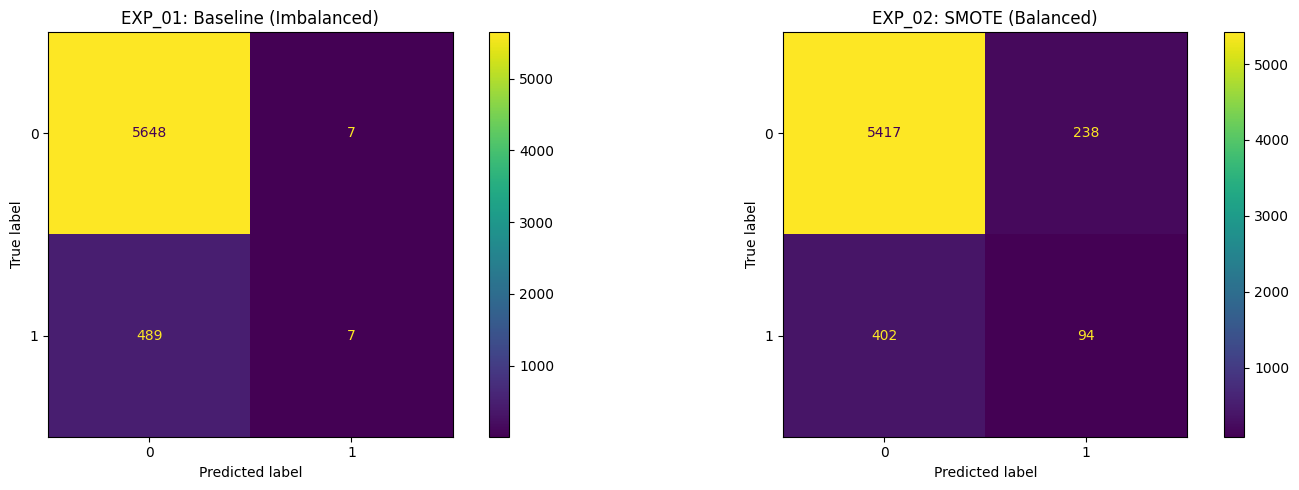

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matrix for Baseline (EXP_01)
cm_base = confusion_matrix(y_test, model.predict(X_test_proc))
ConfusionMatrixDisplay(cm_base).plot(ax=ax[0])
ax[0].set_title("EXP_01: Baseline (Imbalanced)")

# Matrix for SMOTE (EXP_02)
cm_smote = confusion_matrix(y_test, model_smote.predict(X_test_proc))
ConfusionMatrixDisplay(cm_smote).plot(ax=ax[1])
ax[1].set_title("EXP_02: SMOTE (Balanced)")

plt.tight_layout()
plt.savefig(f'{save_path}confusion_matrix_comparison_EXP01_Exp02.png')
print(f"✅ Confusion matrix comparison saved to {save_path}confusion_matrix_comparison.png")
plt.show()

In [15]:
import os

# Define paths
old_path = '/content/drive/MyDrive/Thesis/src/artifacts/'

# Rename existing files to 'v1_baseline'
os.rename(f'{old_path}logistic_reg_smote_model.pkl', f'{old_path}v1_baseline_smote_model.pkl')
os.rename(f'{old_path}X_test_final.csv', f'{old_path}v1_X_test_baseline.csv')
os.rename(f'{old_path}y_test_final.csv', f'{old_path}v1_y_test_baseline.csv')

print("✅ Old artifacts archived as 'v1_baseline'. Ready for version 0.25.")

✅ Old artifacts archived as 'v1_baseline'. Ready for version 0.25.


In [16]:
import joblib

save_path = '/content/drive/MyDrive/Thesis/src/artifacts/'

# Save as the main files so Phase 4 picks them up automatically
joblib.dump(model_smote, f'{save_path}logistic_reg_smote_model.pkl')
joblib.dump(preprocessor, f'{save_path}preprocessor_pipeline.pkl')
X_test.to_csv(f'{save_path}X_test_final.csv', index=False)
y_test.to_csv(f'{save_path}y_test_final.csv', index=False)

print("✅ V2 Artifacts saved. You can now run your Confusion Matrix cell again to see the improvement.")

✅ V2 Artifacts saved. You can now run your Confusion Matrix cell again to see the improvement.


In [17]:
import joblib
import os

# 1. Define the artifact path
artifacts_path = '/content/drive/MyDrive/Thesis/src/artifacts/'
os.makedirs(artifacts_path, exist_ok=True)

# 2. Extract the actual feature names used by the model
# Replace 'preprocessor' with the name of your ColumnTransformer/Pipeline object
try:
    feature_names = preprocessor.get_feature_names_out()

    # 3. Save the names to ensure 'Semantic Mapping' is possible in Notebook 02
    joblib.dump(feature_names, os.path.join(artifacts_path, 'feature_names_v2.pkl'))
    print(f"✅ Feature names successfully persisted: {len(feature_names)} features.")
except NameError:
    print("🚨 Error: Ensure your 'preprocessor' object is defined before running this cell.")

✅ Feature names successfully persisted: 239 features.


In [18]:

# 1. Define the shared artifacts folder
artifacts_path = '/content/drive/MyDrive/Thesis/src/artifacts/'
os.makedirs(artifacts_path, exist_ok=True)

# 2. Export the variables that Notebook 02 is waiting for
# We save X_test as 'X_test_original' because it contains the raw feature names
joblib.dump(X_test, os.path.join(artifacts_path, 'X_test_original.pkl'))
joblib.dump(y_test, os.path.join(artifacts_path, 'y_test.pkl'))

print("✅ Data successfully exported. You can now run Notebook 02.")

✅ Data successfully exported. You can now run Notebook 02.


In [19]:
import joblib
import os

# 1. Define the destination
artifacts_path = '/content/drive/MyDrive/Thesis/src/artifacts/'

# 2. Export X_test so it becomes a permanent file in your Drive
# We use the name 'X_test_original.pkl' to signify this is the raw, unscaled data
joblib.dump(X_test, os.path.join(artifacts_path, 'X_test_original.pkl'))

print("✅ SUCCESS: X_test has been saved to Drive as 'X_test_original.pkl'")

✅ SUCCESS: X_test has been saved to Drive as 'X_test_original.pkl'


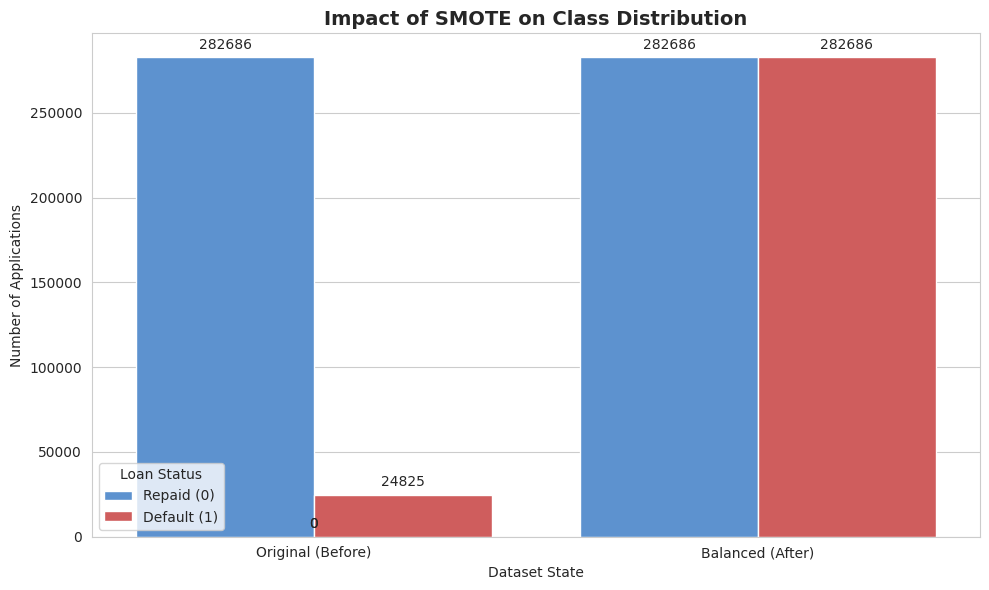

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mock data based on Home Credit proportions
data = {
    'Status': ['Original (Before)', 'Original (Before)', 'Balanced (After)', 'Balanced (After)'],
    'Class': ['Repaid (0)', 'Default (1)', 'Repaid (0)', 'Default (1)'],
    'Count': [282686, 24825, 282686, 282686] # Standard proportions
}
df_plot = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Status', y='Count', hue='Class', data=df_plot, palette=['#4A90E2', '#E24A4A'])

plt.title('Impact of SMOTE on Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Applications')
plt.xlabel('Dataset State')
plt.legend(title='Loan Status')

# Adding count labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

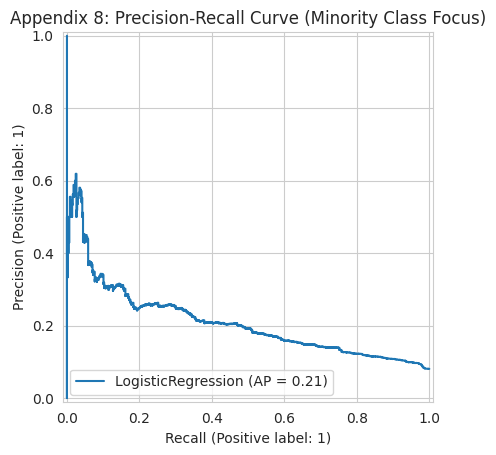

In [21]:
from sklearn.metrics import PrecisionRecallDisplay
# Assuming 'model' and 'X_test', 'y_test' are defined in Notebook 01
PrecisionRecallDisplay.from_estimator(model, X_test_proc, y_test)
plt.title("Appendix 8: Precision-Recall Curve (Minority Class Focus)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueE

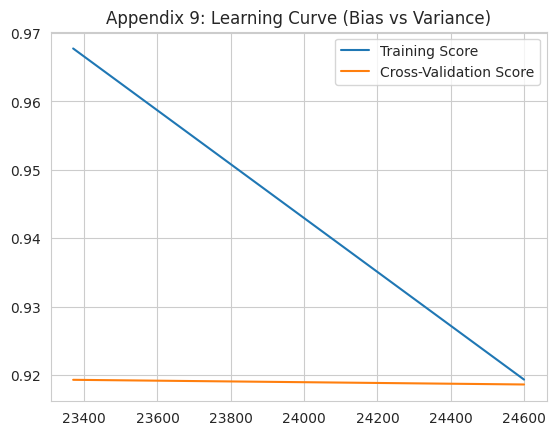

In [22]:
from sklearn.model_selection import learning_curve, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

# Preprocess the entire X dataset using the already fitted preprocessor
X_proc_full = preprocessor.transform(X)

# Define custom train_sizes as fractions.
# Increasing the minimum fraction to a high value (e.g., 0.9) ensures
# that even the smallest training subset contains enough minority class samples.
custom_train_sizes_fractions = np.linspace(0.9, 1.0, 3) # 3 points from 90% to 100%

# Use StratifiedKFold explicitly for cross-validation to maintain class balance in folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_proc_full,
    y,
    cv=cv, # Use explicit StratifiedKFold
    train_sizes=custom_train_sizes_fractions, # Use custom train_sizes as fractions
    n_jobs=-1 # Use all available cores for faster computation
)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Validation Score')
plt.title("Appendix 9: Learning Curve (Bias vs Variance)")
plt.legend()
plt.show()

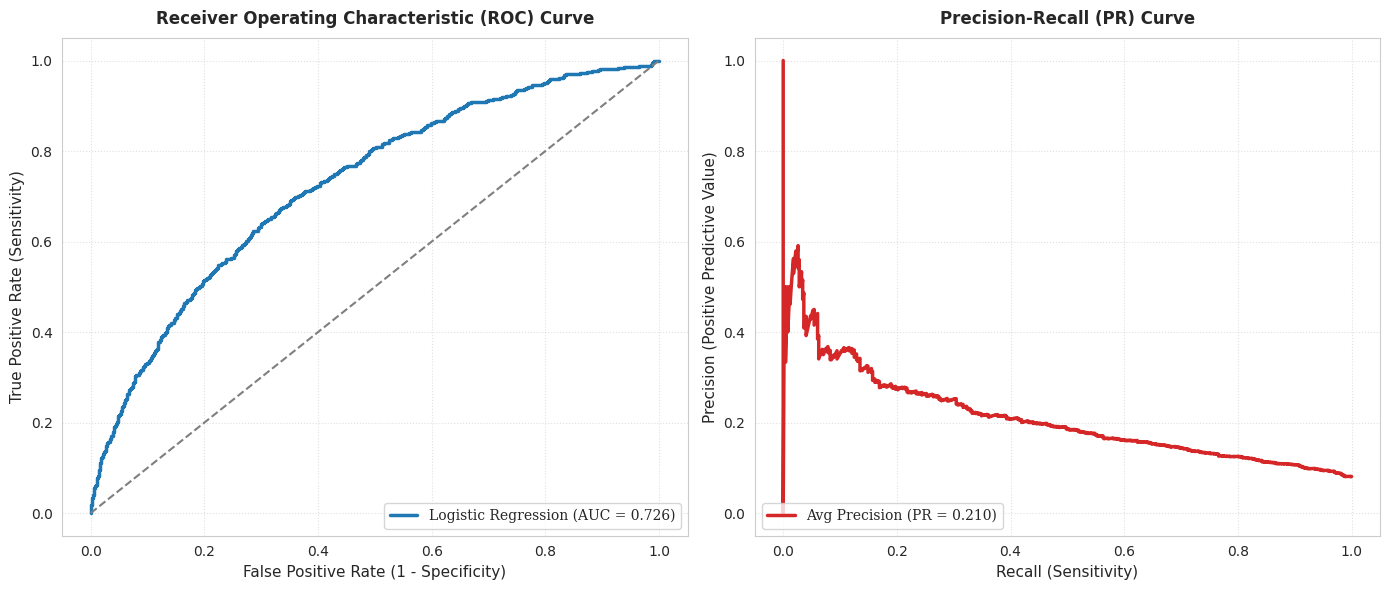

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Compute metrics using your model's true test targets and predicted probabilities
fpr, tpr, _ = roc_curve(y_test, y_prob_smote)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_prob_smote)
avg_precision = average_precision_score(y_test, y_prob_smote)

# Initialize side-by-side evaluation layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plt.rcParams['font.family'] = 'serif'

# Panel A: ROC Boundary Parity Check
ax1.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.5, linestyle='--')
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc="lower right", frameon=True)

# Panel B: Precision-Recall Minority Class Check
ax2.plot(recall, precision, color='#d62728', lw=2.5, label=f'Avg Precision (PR = {avg_precision:.3f})')
ax2.set_title('Precision-Recall (PR) Curve', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Recall (Sensitivity)', fontsize=11)
ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc="lower left", frameon=True)

plt.tight_layout()
plt.savefig('artifacts_model_performance_curves.png', dpi=300, bbox_inches='tight')
plt.show()